<a href="https://colab.research.google.com/github/estefania-apaza/state-capacity-protest-peru/blob/main/SMOTE_Base-Variable-Y.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Avance de la Base de Datos
Propuesta de Investigación
- Curso: Estadística para el Análisis Político 2
- Nombres: Estefanía Apaza (20230487) y Diego Luyo (20230934)


Insumos

[Libro de Códigos](https://docs.google.com/spreadsheets/d/1U5zJE58q_83H3Lc0-il9jx8QrDb9EX78/edit?gid=266433641#gid=266433641)

[Base de Eventos de Protesta](https://github.com/estefania-apaza/state-capacity-protest-peru/blob/main/Base%20de%20Eventos%20de%20Protesta%20del%20Peru%CC%81_1980_2025.csv) (Aragón, et al.) - Necesario subirla a Google Colab para correr el código

### Avance de la variable Y


**1. Limpieza y filtrado de la base de datos**

In [4]:
import pandas as pd

# Cargado de la base de la Escuela de Gobierno y Políticas Públicas PUCP
file_path = "Base de Eventos de Protesta del Perú_1980_2025.csv"
df_egpp = pd.read_csv(file_path, sep=';', encoding='latin-1', on_bad_lines='skip')

# Limpieza de nombres de columnas
df_egpp.columns = df_egpp.columns.str.strip().str.lower()
df_egpp.columns = df_egpp.columns.str.replace('ñ', 'n').str.replace('á', 'a').str.replace('é', 'e').str.replace('í', 'i').str.replace('ó', 'o').str.replace('ú', 'u')

# Selección preliminar de columnas
columnas_analisis = [
    'id', 'ano', 'mes_id', 'presidente_id',
    'region_id', 'provincia_id', 'distrito_id',
    'sector_id_1', 'actor_1_id', 'sector_id_2', 'actor_2_id',
    'accion_1_id', 'accion_2_id', 'accion_3_id', 'accion_4_id',
    'duracion_horas', 'numero_participantes',
    'numero_heridos', 'numero_muertos', 'numero_detenidos',
    'adversario_id', 'institucion_id',
    'reclamo_id', 'sub_reclamo_id']

# Creación de la base preliminar
df_preliminar = df_egpp[[c for c in columnas_analisis if c in df_egpp.columns]].copy()

df_preliminar.columns
df_preliminar.head(5)

,id,ano,mes_id,presidente_id,region_id,provincia_id,distrito_id,sector_id_1,actor_1_id,sector_id_2,...,accion_4_id,duracion_horas,numero_participantes,numero_heridos,numero_muertos,numero_detenidos,adversario_id,institucion_id,reclamo_id,sub_reclamo_id
0,1,1980,1,1,15,1501,150101,18,102,NaN,...,NaN,24.0,NaN,NaN,NaN,NaN,9,909.0,1,105
1,2,1980,1,1,15,1501,150101,13,104,NaN,...,NaN,24.0,2500.0,NaN,NaN,NaN,7,712.0,1,101
2,3,1980,1,1,15,1501,150108,103,206,NaN,...,NaN,24.0,NaN,15.0,NaN,NaN,1,105.0,4,407
3,4,1980,1,1,15,1501,150101,26,127,NaN,...,NaN,24.0,NaN,NaN,NaN,NaN,9,909.0,1,104
4,5,1980,1,1,8,801,80101,21,119,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5,508.0,1,109


**2. Definición del umbral de la violencia para la variable dependiente: "Protesta violenta"**

Criterios

*   Alguna de las acciones implica violencia según el Libro de Códigos
*   Existe alguna víctima física



In [5]:
def variable_violencia(row):
    # Códigos de Acción seleccionados por implicar violencia según el Libro de Códigos (107-114, 119, 123)
    codigo_violencia = [107, 108, 109, 110, 111, 112, 113, 114, 119, 123]

    # Extraemos los IDs mencionados de las columnas de Acción (1-4)
    acciones = [row.get('accion_1_id'), row.get('accion_2_id'),
                row.get('accion_3_id'), row.get('accion_4_id')]

    # Criterio 1 - Acción implica violencia
    es_accion_violenta = any(acc in codigo_violencia for acc in acciones)

    # Criterio 2 - Existen víctimas físicas
    muertos = pd.to_numeric(row.get('numero_muertos', 0), errors='coerce') or 0
    heridos = pd.to_numeric(row.get('numero_heridos', 0), errors='coerce') or 0
    tiene_victimas = (muertos > 0 or heridos > 0)

    if es_accion_violenta or tiene_victimas:
        return 1
    return 0

# Creamos la variable dependiente con la función
df_preliminar['violencia_y'] = df_preliminar.apply(variable_violencia, axis=1)

print(df_preliminar['violencia_y'].value_counts())

violencia_y
0    21144
1     3882
Name: count, dtype: int64


In [6]:
columnas_final = [
    'id', 'ano', 'mes_id', 'presidente_id',
    'region_id', 'provincia_id', 'distrito_id',
    'sector_id_1', 'actor_1_id', 'sector_id_2', 'actor_2_id',
    'duracion_horas', 'numero_participantes','numero_detenidos',
    'adversario_id', 'institucion_id',
    'reclamo_id', 'sub_reclamo_id', 'violencia_y']

# Creación de la base final para la variable Y
df_final = df_preliminar[[c for c in columnas_final if c in df_preliminar.columns]].copy()

df_final.head(5)

,id,ano,mes_id,presidente_id,region_id,provincia_id,distrito_id,sector_id_1,actor_1_id,sector_id_2,actor_2_id,duracion_horas,numero_participantes,numero_detenidos,adversario_id,institucion_id,reclamo_id,sub_reclamo_id,violencia_y
0,1,1980,1,1,15,1501,150101,18,102,NaN,NaN,24.0,NaN,NaN,9,909.0,1,105,0
1,2,1980,1,1,15,1501,150101,13,104,NaN,NaN,24.0,2500.0,NaN,7,712.0,1,101,0
2,3,1980,1,1,15,1501,150108,103,206,NaN,NaN,24.0,NaN,NaN,1,105.0,4,407,1
3,4,1980,1,1,15,1501,150101,26,127,NaN,NaN,24.0,NaN,NaN,9,909.0,1,104,0
4,5,1980,1,1,8,801,80101,21,119,NaN,NaN,NaN,NaN,NaN,5,508.0,1,109,0


**3. Revisión de la base**

In [7]:
print("Descripción del avance de la Base de Datos")
print(f"Columnas: {len(df_final.columns)}")
print(f"Observaciones: {len(df_final)}")
print("\nConteo de la Variable Dependiente (Protesta violenta):")
print(df_final['violencia_y'].value_counts())

Descripción del avance de la Base de Datos
Columnas: 19
Observaciones: 25026

Conteo de la Variable Dependiente (Protesta violenta):
violencia_y
0    21144
1     3882
Name: count, dtype: int64


**Referencias**

Aragón, Jorge, Moisés Arce, Renzo Aurazo y Omar Coronel. 2025. Base de Eventos de Protestas del Perú, Versión Agosto 2025. Lima: Pontificia Universidad Católica del Perú-PUCP

Aragón, Jorge, Moisés Arce, Renzo Aurazo y Omar Coronel. 2025. Base de Eventos de Protestas del Perú: Libro de Códigos, Versión Agosto 2025. Lima: Pontificia Universidad Católica del Perú-PUCP

### Limpieza de duplicados y minimización del sesgo de clases

In [8]:
# Ordenamos la base: los 1 (violencia) primero, los 0 (no violento) después
df_preliminar = df_preliminar.sort_values(by='violencia_y', ascending=False)

# Definimos nuestra llave de identidad
llave_duplicados = ['ano', 'mes_id', 'region_id', 'provincia_id', 'distrito_id', 'actor_1_id', 'reclamo_id']

# Borramos duplicados manteniendo la primera observación
antes = len(df_preliminar)
df_preliminar = df_preliminar.drop_duplicates(subset=llave_duplicados, keep='first')
despues = len(df_preliminar)

print(f"Filas eliminadas: {antes - despues}")
print(f"Nueva distribución de Y:\n{df_preliminar['violencia_y'].value_counts()}")

Filas eliminadas: 7311
Nueva distribución de Y:
violencia_y
0    14668
1     3047
Name: count, dtype: int64


In [9]:
# Acciones simbólicas para filtrar y eliminar
# 127: Olla común, 122: Lavados, 115: Mitín, 129: Protesta simbólica, 125: Cacerolazo
acciones_simbolicas = [127, 122, 115, 129, 125]

def es_evento_prescindible(row):
    acciones_evento = [row['accion_1_id'], row['accion_2_id'],
                       row['accion_3_id'], row['accion_4_id']]
    acciones_reales = [int(a) for a in acciones_evento if pd.notnull(a)]
    # Si todas son simbólicas, el evento es prescindible
    return all(a in acciones_simbolicas for a in acciones_reales)

# Aplicamos el filtro para quedarnos con las no prescindible
df_preliminar = df_preliminar[~df_preliminar.apply(es_evento_prescindible, axis=1)]

print(f"Nueva distribución tras quitar acciones simbólicas puras:\n{df_preliminar['violencia_y'].value_counts()}")

Nueva distribución tras quitar acciones simbólicas puras:
violencia_y
0    14540
1     3047
Name: count, dtype: int64


### Avance de las variables de control

1. **Protesta masiva**

In [10]:
# Evaluamos corte para protesta masiva

df_preliminar['numero_participantes'].quantile([0.25, 0.5, 0.75, 0.9, 0.95])

,numero_participantes
0.25,150.0
0.50,500.0
0.75,3000.0
0.90,10000.0
0.95,23000.0


In [11]:
# Seleccionamos el umbral

umbral_elegido = 3500

# Elaboramos la variable

df_preliminar['protesta_masiva'] = (df_preliminar['numero_participantes'] >= umbral_elegido).astype(int)

print(df_preliminar['protesta_masiva'].value_counts())

protesta_masiva
0    16952
1      635
Name: count, dtype: int64


2. **Número de eventos**

In [12]:
# Agrupamos para contar cuántas protestas hubo por provincia cada mes
conteo_mensual = df_preliminar.groupby(['provincia_id', 'ano', 'mes_id']).size().reset_index(name='n_eventos_mes')

# Ordenamos para que el desplazamiento sea cronológico por provincia
conteo_mensual = conteo_mensual.sort_values(['provincia_id', 'ano', 'mes_id'])

# Creamos la sección del valor del mes anterior se pone en la fila del mes actual
conteo_mensual['numero_eventos_previos'] = conteo_mensual.groupby('provincia_id')['n_eventos_mes'].shift(1).fillna(0)

df_preliminar = pd.merge(
    df_preliminar,
    conteo_mensual[['provincia_id', 'ano', 'mes_id', 'numero_eventos_previos']],
    on=['provincia_id', 'ano', 'mes_id'],
    how='left'
)

df_preliminar['numero_eventos_previos'] = df_preliminar['numero_eventos_previos'].fillna(0)

print("--- RESUMEN DE LA BASE ACTUALIZADA ---")
print(f"Total de filas: {len(df_preliminar)}")
print(f"Protestas masivas (>= 3500): {df_preliminar['protesta_masiva'].sum()}")
print("\nMuestra de inercia (eventos el mes pasado):")
print(df_preliminar[['provincia_id', 'ano', 'mes_id', 'protesta_masiva', 'numero_eventos_previos']].tail())

--- RESUMEN DE LA BASE ACTUALIZADA ---
Total de filas: 17587
Protestas masivas (>= 3500): 635

Muestra de inercia (eventos el mes pasado):
       provincia_id   ano  mes_id  protesta_masiva  numero_eventos_previos
17582           807  2024      11                0                     1.0
17583          1401  2024      12                0                     2.0
17584          1501  2024      12                0                    24.0
17585          1501  2024      12                0                    24.0
17586           501  2024      12                0                     2.0


In [13]:
df_preliminar.columns

Index(['id', 'ano', 'mes_id', 'presidente_id', 'region_id', 'provincia_id',
       'distrito_id', 'sector_id_1', 'actor_1_id', 'sector_id_2', 'actor_2_id',
       'accion_1_id', 'accion_2_id', 'accion_3_id', 'accion_4_id',
       'duracion_horas', 'numero_participantes', 'numero_heridos',
       'numero_muertos', 'numero_detenidos', 'adversario_id', 'institucion_id',
       'reclamo_id', 'sub_reclamo_id', 'violencia_y', 'protesta_masiva',
       'numero_eventos_previos'],
      dtype='object')

### Aplicación del SMOTE

In [14]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd
import numpy as np

# Lista de columnas que queremos para el modelo
columnas_potenciales = [
    'ano', 'mes_id', 'presidente_id', 'region_id', 'provincia_id',
    'distrito_id', 'sector_id_1', 'actor_1_id', 'sector_id_2', 'actor_2_id',
    'duracion_horas', 'numero_participantes', 'numero_heridos',
    'numero_muertos', 'numero_detenidos', 'adversario_id', 'institucion_id',
    'reclamo_id', 'sub_reclamo_id', 'protesta_masiva', 'numero_eventos_previos'
]

columnas_X = [c for c in columnas_potenciales if c in df_preliminar.columns]

print(f"Columnas detectadas para el SMOTE: {columnas_X}")

# Limpieza de NaNs
df_pre_smote = df_preliminar.copy()

# Rellenamos numéricas con la mediana y el resto con 0
for col in columnas_X:
    if df_pre_smote[col].dtype in [np.float64, np.int64]:
        df_pre_smote[col] = df_pre_smote[col].fillna(df_pre_smote[col].median())
    else:
        df_pre_smote[col] = df_pre_smote[col].fillna(0)

# Aseguramos que la Y no tenga nulos
df_pre_smote = df_pre_smote.dropna(subset=['violencia_y'])

# 4. Definir X y y
X = df_pre_smote[columnas_X]
y = df_pre_smote['violencia_y']

print(f"Distribución original: {Counter(y)}")

# Aplicar SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print(f"Distribución balanceada: {Counter(y_res)}")

# Crear el DataFrame final
df_balanceado = pd.DataFrame(X_res, columns=columnas_X)
df_balanceado['violencia_y'] = y_res

Columnas detectadas para el SMOTE: ['ano', 'mes_id', 'presidente_id', 'region_id', 'provincia_id', 'distrito_id', 'sector_id_1', 'actor_1_id', 'sector_id_2', 'actor_2_id', 'duracion_horas', 'numero_participantes', 'numero_heridos', 'numero_muertos', 'numero_detenidos', 'adversario_id', 'institucion_id', 'reclamo_id', 'sub_reclamo_id', 'protesta_masiva', 'numero_eventos_previos']
Distribución original: Counter({0: 14540, 1: 3047})
Distribución balanceada: Counter({1: 14540, 0: 14540})





---


In [15]:
# Descarga del avance de la base de datos
from google.colab import files

df_preliminar.to_csv('base_protestas_desbalanceada.csv', index=False, encoding='utf-8-sig')
files.download('base_protestas_desbalanceada.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
# Descarga del avance de la base de datos
from google.colab import files

df_balanceado.to_csv('base_protestas_final.csv', index=False, encoding='utf-8-sig')
files.download('base_protestas_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



---



### Exploración de variable dependiente

**Tabla de estadísticos**

In [24]:
# Seleccionamos variables que son magnitudes reales
variables_analisis = [
    'duracion_horas',
    'numero_participantes',
    'numero_heridos',
    'numero_muertos',
    'numero_detenidos',
    'numero_eventos_previos'
]

cuadro_descriptivo = df_preliminar[variables_analisis].describe().T

cuadro_descriptivo.columns = ['Conteo', 'Media', 'Desv. Estándar', 'Mínimo', '25%', 'Mediana (50%)', '75%', 'Máximo']

print("Cuadro Descriptivo de Variables de Magnitud:")
display(cuadro_descriptivo)

Cuadro Descriptivo de Variables de Magnitud:


,Conteo,Media,Desv. Estándar,Mínimo,25%,Mediana (50%),75%,Máximo
duracion_horas,4125.0,108.093164,394.031747,1.0,24.0,24.0,48.0,12960.0
numero_participantes,2741.0,10827.897848,93081.874742,1.0,150.0,500.0,3000.0,4000000.0
numero_heridos,807.0,10.489467,22.224315,1.0,2.0,4.0,11.0,345.0
numero_muertos,232.0,2.288793,3.792023,1.0,1.0,1.0,2.0,40.0
numero_detenidos,432.0,34.773148,79.908210,1.0,4.0,12.0,28.0,700.0
numero_eventos_previos,17587.0,7.707625,8.877993,0.0,1.0,2.0,13.0,47.0


**1. Protestas por año**

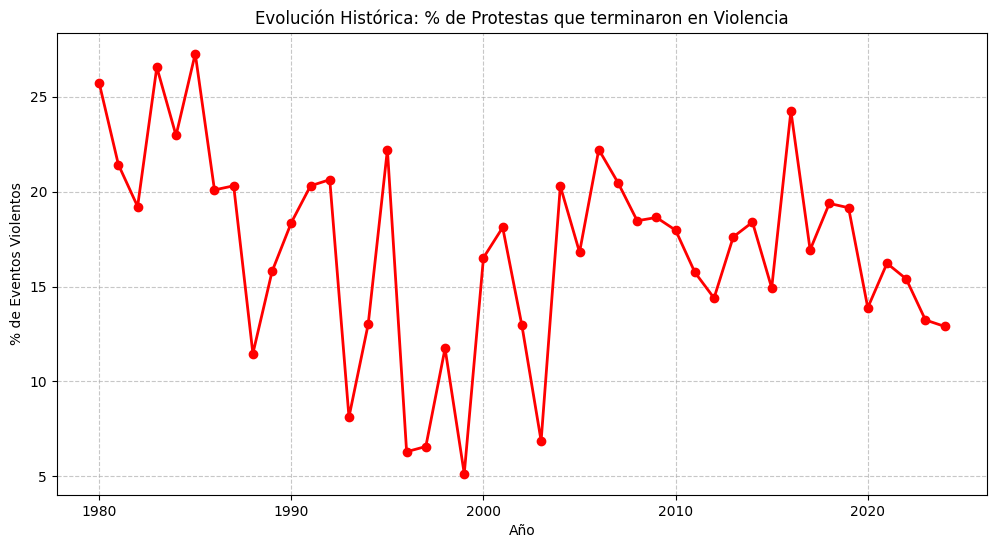

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupamos por año y calculamos el porcentaje de violencia
proporcion_anual = df_preliminar.groupby('ano')['violencia_y'].mean() * 100

plt.figure(figsize=(12, 6))
proporcion_anual.plot(kind='line', marker='o', color='red', linewidth=2)
plt.title('Evolución Histórica: % de Protestas que terminaron en Violencia')
plt.ylabel('% de Eventos Violentos')
plt.xlabel('Año')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**1. Protestas por región**

/tmp/ipykernel_14981/1645550845.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_violencia.values, y=region_violencia.index.astype(str), palette='Reds_r')


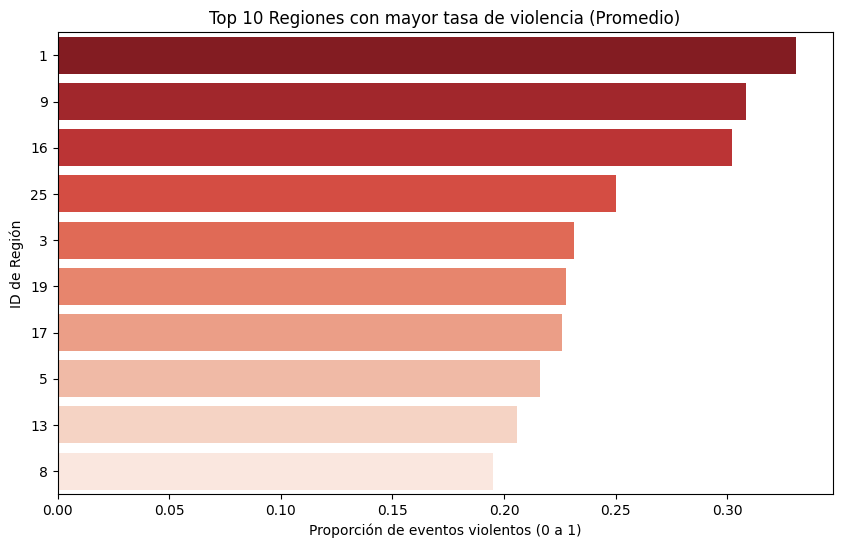

In [20]:
# Calculamos la tasa de violencia por región
region_violencia = df_preliminar.groupby('region_id')['violencia_y'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=region_violencia.values, y=region_violencia.index.astype(str), palette='Reds_r')
plt.title('Top 10 Regiones con mayor tasa de violencia (Promedio)')
plt.xlabel('Proporción de eventos violentos (0 a 1)')
plt.ylabel('ID de Región')
plt.show()

**3. Violencia según protesta masiva**

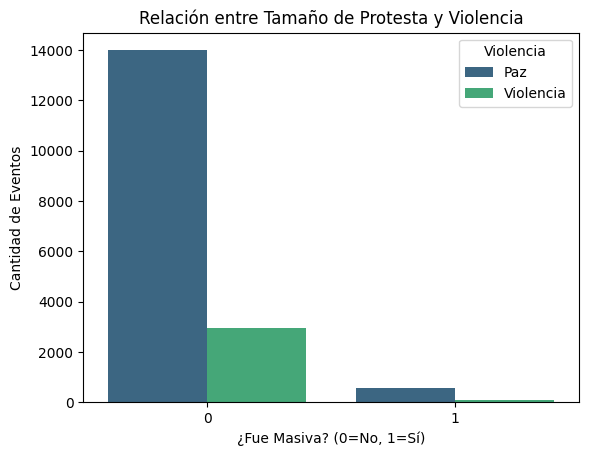

In [22]:
sns.countplot(data=df_preliminar, x='protesta_masiva', hue='violencia_y', palette='viridis')
plt.title('Relación entre Tamaño de Protesta y Violencia')
plt.xlabel('¿Fue Masiva? (0=No, 1=Sí)')
plt.ylabel('Cantidad de Eventos')
plt.legend(title='Violencia', labels=['Paz', 'Violencia'])
plt.show()

**Dependiente previo al SMOTE**

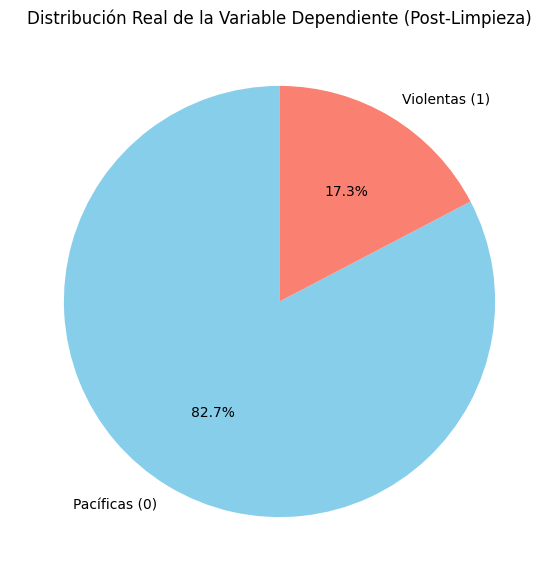

In [21]:
labels = ['Pacíficas (0)', 'Violentas (1)']
counts = df_preliminar['violencia_y'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)
plt.title('Distribución Real de la Variable Dependiente (Post-Limpieza)')
plt.show()